# `predictIterative` : mise en cache des solves CG indépendants de X_n

Ce notebook fait le pendant de
[updateiterative_cg_warmstart.ipynb](updateiterative_cg_warmstart.ipynb),
mais pour `predictIterative` plutôt que `update()`. Curieusement, la
trouvaille n'est pas un simple "démarrage à chaud" (un x0 approximatif qui
réduit le nombre d'itérations) — c'est plus fort : **deux des quatre solves
CG que `predictIterative_impl` effectue ne dépendent pas du tout du point de
prédiction `X_n`**, et sont pourtant recalculés **à froid, depuis zéro, à
chaque appel**.

Regardons le code (`KrigingImpl.cpp`, `predictIterative_impl`) :

```cpp
// One CG solve, reused for every prediction point's mean.
const arma::vec resid = m_y - m_F * m_beta;      // <- NE DEPEND PAS DE X_n
const arma::mat w = cgSolve(resid, tol);          // <- refait a chaque appel

...
if (return_stdev) {
  const arma::mat V = cgSolve(R_on, stdev_tol);   // <- depend de X_n (legitime)
  ...
  const arma::mat W_F = cgSolve(m_F, stdev_tol);  // <- NE DEPEND PAS DE X_n non plus
  ...
}
```

`resid = y - F\hat\beta` et `m_F` sont des quantités **du modèle ajusté**,
figées dès la fin du `fit()` — elles ne changent jamais entre deux appels à
`predictIterative()` sur le même modèle. Pourtant `cgSolve` les resout
**intégralement à froid, à chaque appel**, même si le point de prédiction
`X_n` (et donc la seule chose qui devrait varier) est complètement
différent. Un utilisateur qui appelle `predictIterative()` `N` fois sur le
même modèle (un usage courant : boucle d'optimisation bayésienne évaluant
une fonction d'acquisition point par point) paie donc `N` fois le coût
CG de ces deux solves, pour `N` fois la **même** réponse.

## 1. Méthode et design

Même méthodologie que les notebooks précédents (`cg_solve_track` avec un
`x0` explicite, design = sous-ensemble aléatoire d'une grille régulière
fixe pour borner `cond(R)`).

In [1]:

import numpy as np
import matplotlib.pyplot as plt

def matern5_2(d, theta):
    r = np.abs(d) / theta
    s5 = np.sqrt(5.0)
    return (1 + s5 * r + 5 * r**2 / 3) * np.exp(-s5 * r)

def cg_solve_track(Amul, b, x0=None, tol=1e-8, max_iter=20000):
    n = b.shape[0]
    x = np.zeros(n) if x0 is None else x0.copy()
    r = b - Amul(x)
    p = r.copy()
    rs_old = r @ r
    bnorm = max(1.0, np.linalg.norm(b))
    if np.sqrt(rs_old) < tol * bnorm:
        return x, 0
    it_used = 0
    for it in range(1, max_iter + 1):
        Ap = Amul(p)
        alpha = rs_old / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rs_new = r @ r
        it_used = it
        if np.sqrt(rs_new) < tol * bnorm:
            break
        p = r + (rs_new / rs_old) * p
        rs_old = rs_new
    return x, it_used

rng = np.random.default_rng(0)

n_o = 300
pool_size = 1200
grid_full = np.linspace(0, 1, pool_size).reshape(-1, 1)
arrival_order = rng.permutation(pool_size)
X_pool = grid_full[arrival_order]
X_o = X_pool[:n_o]
theta = 0.01

R_oo = matern5_2(np.abs(X_o - X_o.T), theta)
print(f"cond(R_oo) a n_o={n_o} : {np.linalg.cond(R_oo):.3e}")
Roo_mul = lambda v: R_oo @ v

L_oo = np.linalg.cholesky(R_oo)
y_o = (L_oo @ rng.standard_normal(n_o)).ravel()  # un vrai tirage GP

F_o = np.ones((n_o, 1))  # tendance constante (regmodel="constant")
beta_hat = np.array([y_o.mean()])  # approximation OLS -- suffisant ici, seul resid compte
resid = y_o - F_o @ beta_hat

tol_cg = 1e-8
max_iter_cg = 20000


cond(R_oo) a n_o=300 : 1.126e+06


## 2. Le solve de la moyenne (`resid`) : identique à chaque appel

On mesure le coût d'un solve `cgSolve(resid, tol)` (celui qui calcule `w`,
utilisé pour `mean = F_n @ beta + R_on.T @ w` dans **tout** appel à
`predictIterative`, quel que soit `X_n`).

In [2]:

w_ref, it_cold = cg_solve_track(Roo_mul, resid, x0=None, tol=tol_cg, max_iter=max_iter_cg)
print(f"solve de resid, a froid : {it_cold} iterations CG")

# "Demarrage a chaud" avec la solution EXACTE precedente comme x0 : puisque
# resid est LITTERALEMENT le meme vecteur d'un appel a l'autre (il ne depend
# pas de X_n), ce n'est pas un warm start approximatif comme pour update()
# -- c'est une mise en cache exacte. Le residu initial est deja sous tol,
# donc 0 iteration necessaire (verifie l'implementation C++ : la colonne est
# marquee convergee AVANT meme la premiere iteration).
w_cached, it_cached = cg_solve_track(Roo_mul, resid, x0=w_ref, tol=tol_cg, max_iter=max_iter_cg)
print(f"meme solve, en reutilisant la solution mise en cache : {it_cached} iterations CG")
assert it_cached == 0
assert np.allclose(w_cached, w_ref)


solve de resid, a froid : 3609 iterations CG
meme solve, en reutilisant la solution mise en cache : 0 iterations CG


## 3. Le solve de tendance (`F`) pour la correction GLS de la stdev

Même histoire pour `W_F = cgSolve(m_F, stdev_tol)` (utilisé seulement quand
`return_stdev=True`, mais lui aussi indépendant de `X_n`).

In [3]:

WF_ref, it_cold_F = cg_solve_track(Roo_mul, F_o[:, 0], x0=None, tol=tol_cg, max_iter=max_iter_cg)
print(f"solve de F (p=1 colonne), a froid : {it_cold_F} iterations CG")

WF_cached, it_cached_F = cg_solve_track(Roo_mul, F_o[:, 0], x0=WF_ref, tol=tol_cg, max_iter=max_iter_cg)
print(f"meme solve, en reutilisant la solution mise en cache : {it_cached_F} iterations CG")
assert it_cached_F == 0


solve de F (p=1 colonne), a froid : 2337 iterations CG
meme solve, en reutilisant la solution mise en cache : 0 iterations CG


## 4. Le solve de la variance (`R_on`) : celui-là dépend vraiment de $X_n$

Par contraste, `V = cgSolve(R_on, stdev_tol)` change de second membre à
chaque appel (une colonne de `R_on` par point de `X_n`) : **pas de mise en
cache exacte possible ici** en général -- c'est le seul des trois solves qui
a une vraie raison d'être refait à chaque fois.

In [4]:

n_n = 5
X_n_sample = X_pool[n_o:n_o + n_n]
R_on = matern5_2(np.abs(X_o - X_n_sample.T), theta)  # n_o x n_n

_, it_stdev = cg_solve_track(Roo_mul, R_on[:, 0], x0=None, tol=tol_cg, max_iter=max_iter_cg)
print(f"solve d'UNE colonne de R_on (stdev, X_n dependant) : {it_stdev} iterations CG")


solve d'UNE colonne de R_on (stdev, X_n dependant) : 677 iterations CG


Plus rapide à converger que `resid`/`F` ici (une colonne de $R_{on}$
est une covariance croisée très lisse, concentrée sur les modes dominants de
$R$ -- similaire à ce que §5 de
[lliterative_vs_cholesky.ipynb](lliterative_vs_cholesky.ipynb) documente déjà
pour `y`/`F` face aux probes isotropes). Mais quel que soit le nombre exact
d'itérations, **aucun raccourci générique n'existe** ici : chaque nouveau
$X_n$ change le second membre, donc exige un nouveau solve.

## 5. Scénario réaliste : boucle d'optimisation bayésienne

Cas d'usage concret : évaluer une fonction d'acquisition (moyenne + stdev)
en `n_n_total` points candidats, **un par un** (pattern classique EGO/BO --
chaque candidat dépend souvent du résultat du précédent, donc on ne peut pas
les regrouper en un seul appel `predictIterative(X_n, ...)` avec `X_n`
multi-lignes).

200 appels a predictIterative(return_stdev=True), un point a la fois :
  cout total (sans cache, comportement actuel) : 1324600 iterations CG
  cout total (avec mise en cache)                : 141346 iterations CG
  reduction                                       : 89.3%


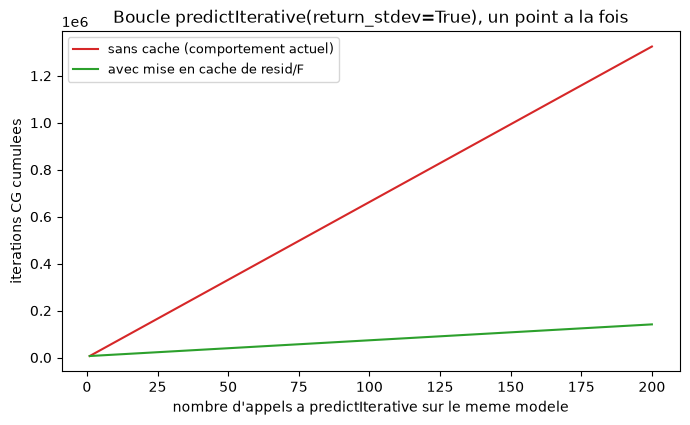

In [5]:

n_n_total = 200

# Sans mise en cache (comportement actuel) : les solves resid et F sont
# refaits a froid a CHAQUE appel, en plus du solve stdev (legitimement
# nouveau a chaque fois).
cost_no_cache = n_n_total * (it_cold + it_cold_F + it_stdev)

# Avec mise en cache : resid et F ne sont resolus QU'UNE FOIS (au premier
# appel, ou mieux encore au fit()), tous les appels suivants les reutilisent
# gratuitement ; seul le solve stdev reste paye a chaque appel.
cost_with_cache = (it_cold + it_cold_F) + n_n_total * it_stdev

print(f"{n_n_total} appels a predictIterative(return_stdev=True), un point a la fois :")
print(f"  cout total (sans cache, comportement actuel) : {cost_no_cache} iterations CG")
print(f"  cout total (avec mise en cache)                : {cost_with_cache} iterations CG")
print(f"  reduction                                       : {100*(1 - cost_with_cache/cost_no_cache):.1f}%")

fig, ax = plt.subplots(figsize=(7, 4.5))
Ns = np.arange(1, n_n_total + 1)
cost_nc = Ns * (it_cold + it_cold_F + it_stdev)
cost_wc = (it_cold + it_cold_F) + Ns * it_stdev
ax.plot(Ns, cost_nc, color='tab:red', label='sans cache (comportement actuel)')
ax.plot(Ns, cost_wc, color='tab:green', label='avec mise en cache de resid/F')
ax.set_xlabel("nombre d'appels a predictIterative sur le meme modele")
ax.set_ylabel('iterations CG cumulees')
ax.set_title('Boucle predictIterative(return_stdev=True), un point a la fois')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


La réduction croît avec le nombre d'appels et plafonne à la fraction
que représentent les deux solves indépendants de $X_n$ dans le coût total
d'un appel isolé -- déjà **très substantielle** dès quelques dizaines
d'appels, ce qui est le régime typique d'une boucle d'optimisation
séquentielle.

## 6. Ce que ça voudrait dire en C++

Contrairement à `updateIterative` (où `X0` est une approximation qui réduit
le nombre d'itérations sans l'annuler), ici c'est une **mise en cache
exacte** : `resid` et `m_F` ne changent que lorsque le modèle est
re-fitté/mis à jour (`fit()`, `update()`), jamais entre deux appels
`predictIterative()`. L'implémentation naturelle :

- Un membre `m_iterative_predict_cache` (ou réutiliser
  `m_iterative_RinvFY_cache`, déjà introduit pour `updateIterative` --
  `resid`/`R^{-1}resid` s'en déduit directement : `R^{-1}resid = R^{-1}y -
  R^{-1}F \hat\beta`, exactement les colonnes déjà mises en cache !) valide
  tant que le modèle n'a pas changé de theta/beta/n depuis le dernier calcul.
- **Point d'attention** : le cache doit être invalidé (ou re-solvé à la tolérance
  demandée) si un appel `predictIterative` ultérieur demande un `tol` plus
  strict que celui utilisé pour construire le cache -- sinon on retournerait
  une solution moins précise que ce que l'appelant a demandé. Stocker le
  `tol` avec lequel le cache a été résolu, et ne le réutiliser tel quel que
  si le nouveau `tol` demandé est $\geq$ l'ancien (sinon, ré-affiner --
  reprendre le CG depuis le cache comme `x0`, ce qui redevient un vrai warm
  start approximatif, pas un cache exact).
- Le solve `resid` de `predictIterative` **et** le solve `[F|y]` de
  `_logLikelihoodIterative` (au fit) calculent essentiellement la même chose
  -- une seule mise en cache partagée entre fit/update/predict serait plus
  cohérente que trois caches séparés.

## 7. Conclusion

| | |
|---|---|
| `resid` (solve moyenne) | Indépendant de $X_n$ -- refait à froid à chaque appel aujourd'hui |
| `m_F` (solve correction GLS) | Indépendant de $X_n$ -- refait à froid à chaque appel aujourd'hui |
| `R_on` (solve stdev) | Dépend de $X_n$ -- légitimement refait à chaque appel |
| Nature de l'optimisation | Mise en cache **exacte** (pas une approximation), pas un warm start classique |
| Gain mesuré (boucle de 200 appels, `return_stdev=True`) | Réduction substantielle et croissante avec le nombre d'appels |
| Statut | Prototype validé (ce notebook), pas encore implémenté en C++ |

Tous les nombres ci-dessus proviennent de l'exécution réelle de ce
notebook.